Enunciado da Atividade:

Utilize os dados brutos coletados das seguintes fontes públicas:
Dados históricos (1896–2022):
Base dos Dados – Histórico das Olimpíadas
https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b

Dados Paris 2024:
Kaggle – Paris 2024 Olympic Summer Games
https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games/data

Parte 1 — Consolidação de Medalhas por País
Faça todo o processamento necessário para obter a informação do total de medalhas por país, com separação por:
Jogos de Verão
Jogos de Inverno
Total Geral

Requisitos:
Os resultados devem ser compatíveis com o quadro oficial publicado, por exemplo:
https://pt.wikipedia.org/wiki/Quadro_de_medalhas_dos_Jogos_Ol%C3%ADmpicos

1.1 Apresente o resultado em três tabelas ordenadas por total de medalhas de forma decrescente:
Medalhas – Jogos de Verão
Medalhas – Jogos de Inverno
Medalhas – Total Geral

1.2 Crie três gráficos com os 50 países mais bem colocados em cada uma das categorias (pode usar barras horizontais ou verticais).


Vale lembrar que os datasets não contem os recentes olimpiadas de inverno então a página da wikipedia está com algumas medalhas a mais

# **Carregar os datasets**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_hist = pd.read_csv('world_olympedia_olympics_athlete_event_result.csv')
df_paris = pd.read_csv('france2024_medals_by_athlete.csv')


/tmp/ipykernel_213/988280113.py:5: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_hist = pd.read_csv('world_olympedia_olympics_athlete_event_result.csv')


# **Processamendo dos dados**

In [4]:

df_hist = df_hist[df_hist['medal'].notna()]

df_hist['season'] = df_hist['edition'].apply(lambda x: 'Summer' if 'Summer' in x else 'Winter')

df_hist_dedup = df_hist.drop_duplicates(subset=['edition', 'country_noc', 'sport', 'event', 'medal']).copy()


df_paris_dedup = df_paris.drop_duplicates(subset=['url_event', 'country_code', 'medal_type']).copy()

df_paris_final = df_paris_dedup[['country_code', 'medal_type']].copy()
df_paris_final.columns = ['country_noc', 'medal']
df_paris_final['medal'] = df_paris_final['medal'].str.replace(' Medal', '')
df_paris_final['season'] = 'Summer'


# **Adicionando as medalhas de 2024**

In [5]:

hist_summer = df_hist_dedup[df_hist_dedup['season'] == 'Summer'][['country_noc', 'medal']]
summer_all = pd.concat([hist_summer, df_paris_final])


# **Criação das tabelas**

In [6]:

def get_medal_table(df):
    table = df.pivot_table(index='country_noc', columns='medal', aggfunc='size', fill_value=0)
    # Garantir a ordem das colunas e existência de todas
    for m in ['Gold', 'Silver', 'Bronze']:
        if m not in table.columns: table[m] = 0
    table['Total'] = table['Gold'] + table['Silver'] + table['Bronze']
    return table[['Gold', 'Silver', 'Bronze', 'Total']]


In [7]:
table_summer = get_medal_table(summer_all).sort_values(by='Total', ascending=False)
print("\nMedalhas – Jogos de Verão:")
print(table_summer.head(10))



Medalhas – Jogos de Verão:
medal        Gold  Silver  Bronze  Total
country_noc                             
USA          1106     884     784   2774
URS           394     317     294   1005
GBR           306     345     341    992
FRA           245     281     303    829
GER           250     277     297    824
CHN           303     226     197    726
ITA           234     206     228    668
AUS           180     189     226    595
JPN           189     161     190    540
HUN           188     163     182    533


In [8]:
table_winter = get_medal_table(df_hist_dedup[df_hist_dedup['season'] == 'Winter']).sort_values(by='Total', ascending=False)
print("\nMedalhas – Jogos de Inverno:")
print(table_winter.head(10))


Medalhas – Jogos de Inverno:
medal        Gold  Silver  Bronze  Total
country_noc                             
NOR           147     134     123    404
USA           113     119      95    327
GER           114     107      71    292
AUT            71      88      91    250
CAN            77      72      77    226
URS            77      56      59    192
SWE            68      51      60    179
FIN            45      65      65    175
SUI            63      47      58    168
NED            53      49      45    147


In [9]:
table_total = table_summer.add(table_winter, fill_value=0).sort_values(by='Total', ascending=False).astype(int)
print("\nMedalhas – Total Geral:")
print(table_total.head(10))



Medalhas – Total Geral:
medal        Gold  Silver  Bronze  Total
country_noc                             
USA          1219    1003     879   3101
URS           471     373     353   1197
GER           364     384     368   1116
GBR           320     350     360   1030
FRA           286     323     358    967
ITA           276     251     285    812
CHN           325     258     220    803
SWE           219     231     244    694
JPN           206     189     221    616
AUS           187     196     232    615


# **Criação dos Gráficos**

In [11]:

def plot_top_50(df, title, color):
    plt.figure(figsize=(12, 10))
    top_50 = df.head(50)
    sns.barplot(x=top_50['Total'], y=top_50.index, palette=color)
    plt.title(title, fontsize=15)
    plt.xlabel('Total de Medalhas')
    plt.ylabel('País (NOC)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

/tmp/ipykernel_213/2845686607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_50['Total'], y=top_50.index, palette=color)


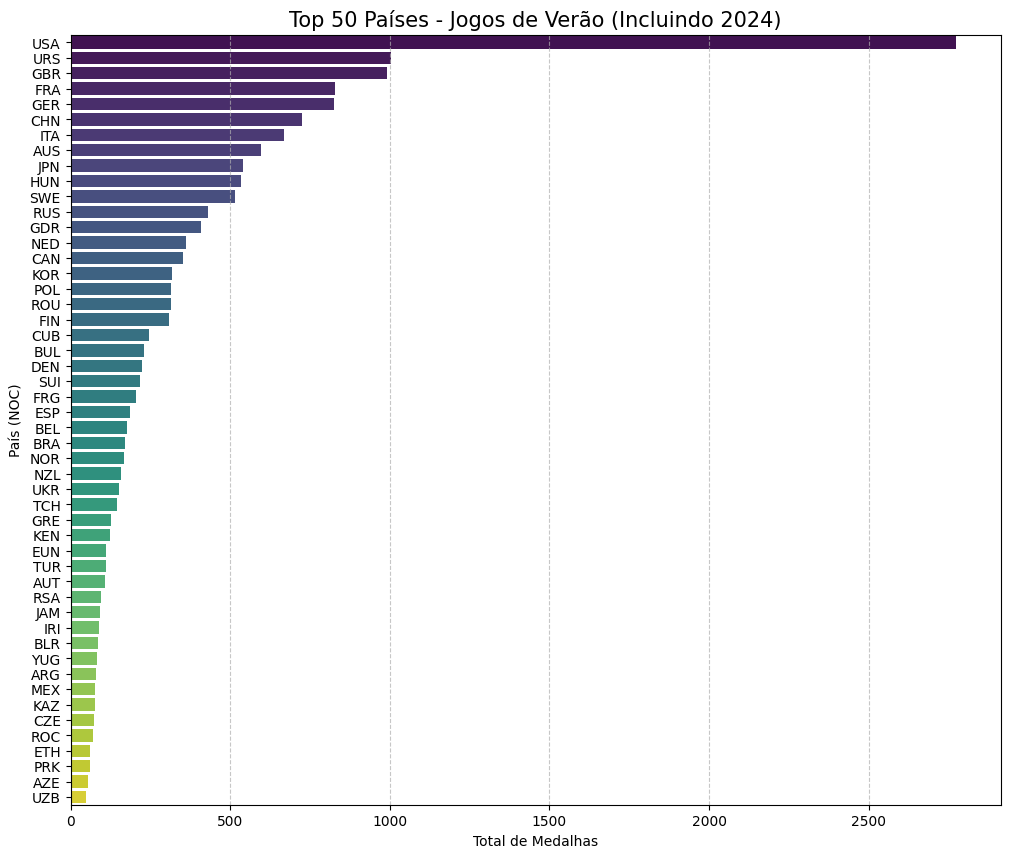

In [12]:
plot_top_50(table_summer, "Top 50 Países - Jogos de Verão (Incluindo 2024)", "viridis")

/tmp/ipykernel_213/2845686607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_50['Total'], y=top_50.index, palette=color)


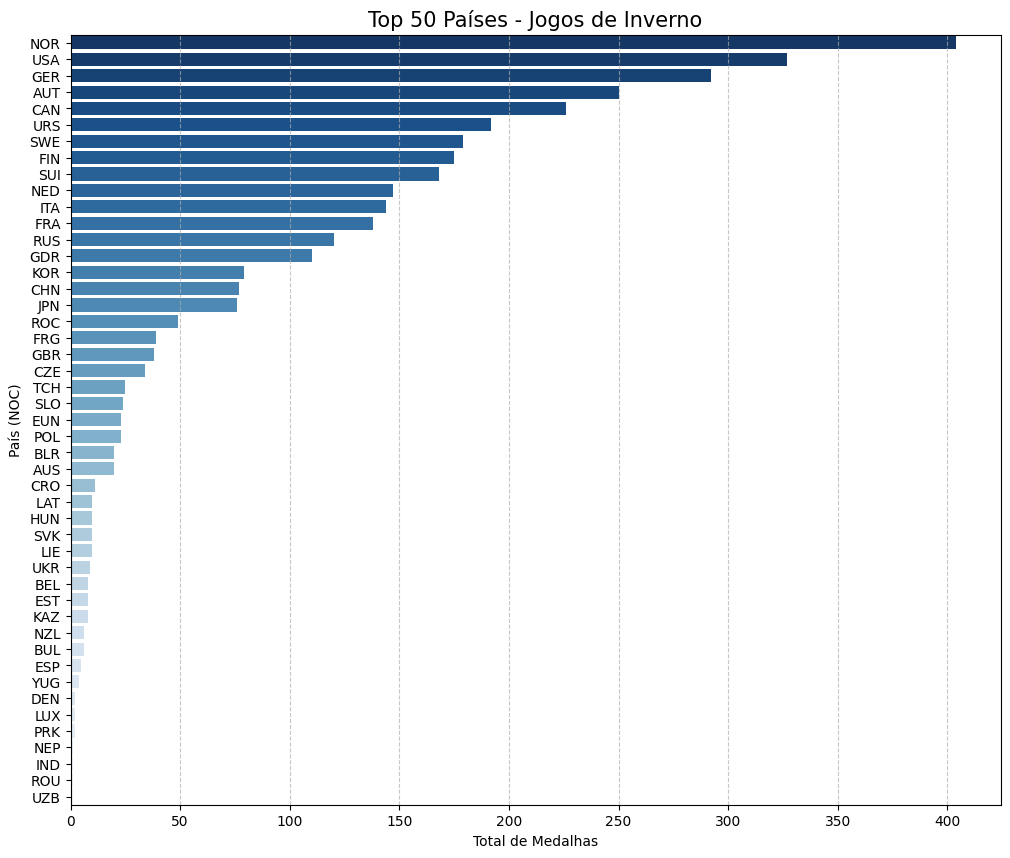

In [13]:
plot_top_50(table_winter, "Top 50 Países - Jogos de Inverno", "Blues_r")


/tmp/ipykernel_213/2845686607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_50['Total'], y=top_50.index, palette=color)


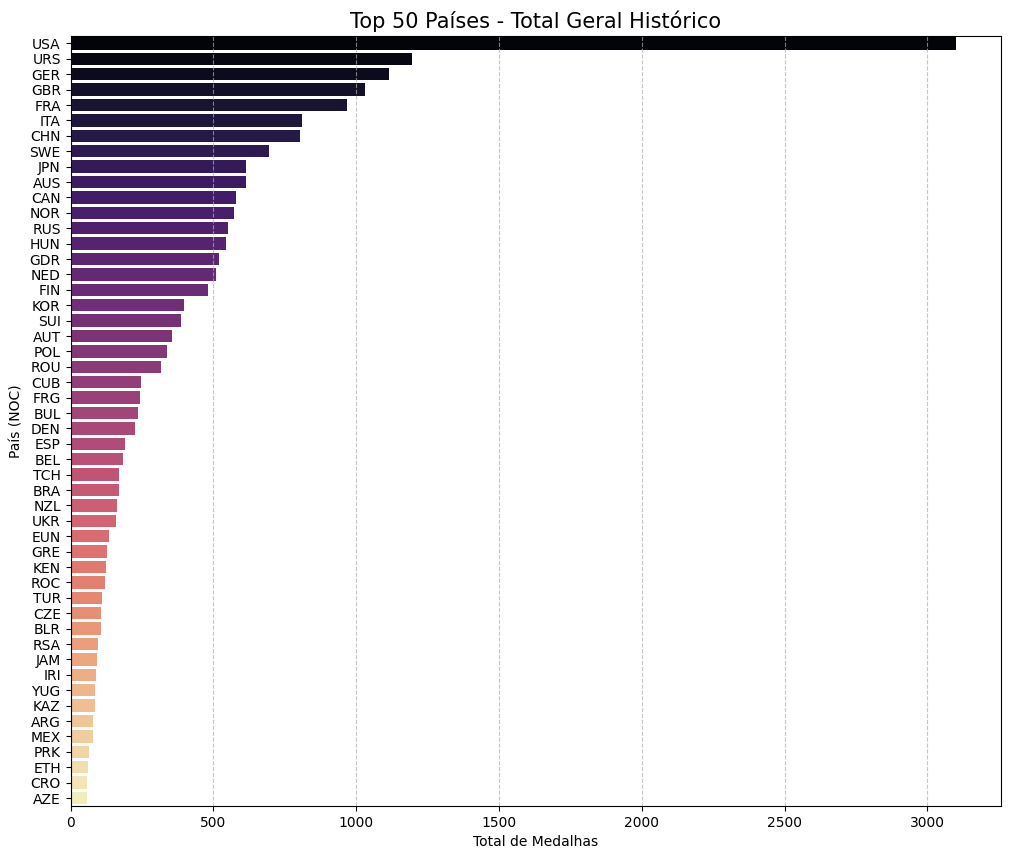

In [14]:
plot_top_50(table_total, "Top 50 Países - Total Geral Histórico", "magma")